1. Viết chương trình chọn LangBiang trong ảnh Đà lạt từ thư mục exercise. Tịnh tiến vùng chọn sang phải 100px. Sử dụng phương pháp Otsu để phân vùng LangBiang theo ngưỡng 0.3. Lưu vào máy với tên lang_biang.jpg và hiển thị trên màn hình.

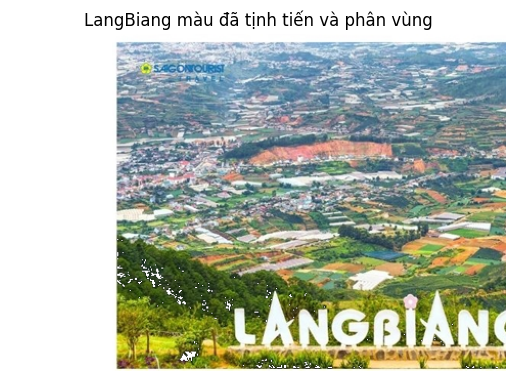

In [ ]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
import scipy.ndimage as nd
from skimage.filters import threshold_otsu
from PIL import Image

data = iio.imread("images/dalat.jpg")
bmg = data[15:345, 15:500]

bmg_shifted = nd.shift(bmg, shift=(0, 100, 0))  

h, w, c = bmg_shifted.shape
canvas = np.ones((h, w, c), dtype=bmg.dtype) * 255
canvas[:, :, :] = bmg_shifted

gray = np.dot(canvas[...,:3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)
thres = threshold_otsu(gray)
binary = gray > (0.3 * thres)

color_result = canvas.copy()
color_result[~binary] = 255 

Image.fromarray(color_result).save("images/lang_biang.jpg")
plt.imshow(color_result)
plt.title('LangBiang màu đã tịnh tiến và phân vùng')
plt.axis('off')
plt.show()

2. Viết chương trình chọn Hồ Xuân Hương trong ảnh Đà Lạt từ thư mục exercise. Xoay đối tượng vừa chọn 1 góc 45 độ và dùng phương pháp Adaptive Thresholding với ngưỡng 60 và lưu vào máy với tên là ho_xuan_huong.jpg.

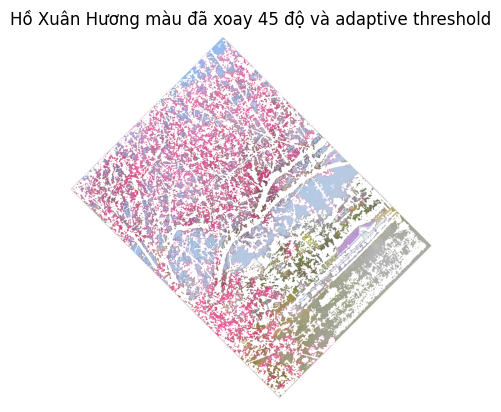

In [37]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
import scipy.ndimage as nd
from PIL import Image
from skimage.filters import threshold_local

data = iio.imread("images/dalat.jpg")
bmg = data[15:685, 505:995]
bdata = nd.rotate(bmg, 45)

gray = np.dot(bdata[...,:3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)
block_size = 61
adaptive_thresh = threshold_local(gray, block_size, offset=0)
binary = gray > adaptive_thresh
color_result = bdata.copy()
color_result[~binary] = 255

Image.fromarray(color_result.astype(np.uint8)).save("images/ho_xuan_huong.jpg")
plt.imshow(color_result.astype(np.uint8))
plt.title('Hồ Xuân Hương màu đã xoay 45 độ và adaptive threshold')
plt.axis('off')
plt.show()

3. Viết chương trình chọn Quảng trường Lâm Viên trong ảnh Đà Lạt từ thư mục exercise. Dùng phương pháp Coordinate Mapping và Binary Closing cho vùng vừa chọn. Lưu vào máy với tên là quan_truong_lam_vien.jpg.

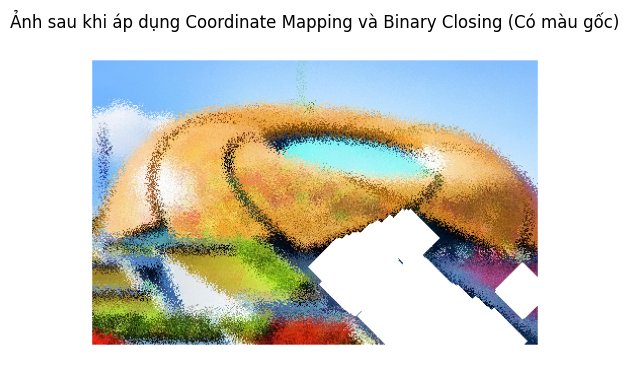

In [57]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
import scipy.ndimage as nd
from PIL import Image
from skimage.filters import threshold_otsu

data = iio.imread("images/dalat.jpg")

bmg = data[15:345, 1000:(-10)].copy()
V, H = bmg.shape[:2]
M=np.indices((V, H))
d=5
q=2*d*np.random.ranf(M.shape) - d
mp = (M + q).astype(int)
d1 = np.zeros_like(bmg)
for i in range(bmg.shape[2]): # Iterate through R, G, B channels
    d1[:, :, i] = nd.map_coordinates(bmg[:, :, i], mp, order=1, mode='reflect')
gray_d1 = np.dot(d1[...,:3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)
thresh = threshold_otsu(gray_d1)
binary_mask = gray_d1 > thresh
s = np.array([[0, 1, 0],
              [1, 1, 1],
              [0, 1, 0]])
iterations = 25
closed_mask = nd.binary_closing(binary_mask, structure=s, iterations=iterations)
final_colored_result = d1.copy()
final_colored_result[~closed_mask] = 255
output_image = data.copy()
output_image[15:345, 1000:(-10)] = final_colored_result

Image.fromarray(final_colored_result.astype(np.uint8)).save("images/quan_truong_lam_vien.jpg")
plt.imshow(final_colored_result.astype(np.uint8))
plt.title("Ảnh sau khi áp dụng Coordinate Mapping và Binary Closing (Có màu gốc)")
plt.axis('off')
plt.show()

4. Viết chương trình cho phép người dùng nhập chức  năng muốn xử lý. (Có thể chọn 1 chức năng duy nhất hoặc kết hợp 2 chức năng của geometric_transformation và segment).

--- Menu Xử lý Ảnh ---
Chọn chức năng để áp dụng:
1. Geometric_transformation
   1.1. coordinate_mapping
   1.2. Rotate
   1.3. Scale
   1.4. Shift
2. Segment
   2.1. Adaptive_thresholding
   2.2. Binary_dilation
   2.3. Binary_erosion
   2.4. Otsu
3. Áp dụng cả 2 (geometric_transformation + segment)
4. Exit
Đang áp dụng biến đổi hình học: shift_image
Đang áp dụng chức năng phân đoạn: otsu_thresholding


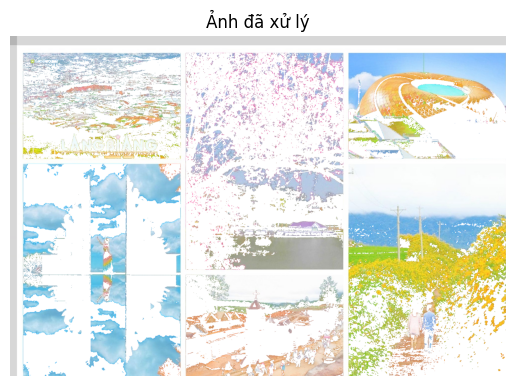

In [67]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import scipy.ndimage as nd
from skimage.filters import threshold_local, threshold_otsu
from skimage.morphology import binary_dilation, binary_erosion 

def load_image(path="images/dalat.jpg"):
    try:
        img = Image.open(path).convert('RGB') 
        return np.array(img)
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy ảnh tại {path}")
        return None

def display_image(image_array, title="Ảnh đã xử lý"):
    plt.imshow(image_array)
    plt.title(title)
    plt.axis('off')
    plt.show()

def get_grayscale(image_array):
    return np.dot(image_array[...,:3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)

def coordinate_mapping(image_array, d=5):
    V, H = image_array.shape[:2]
    M = np.indices((V, H))
    q = 2 * d * np.random.ranf(M.shape) - d
    mp = (M + q).astype(int)

    result_image = np.zeros_like(image_array)
    if image_array.ndim == 3: 
        for i in range(image_array.shape[2]):
            result_image[:, :, i] = nd.map_coordinates(image_array[:, :, i], mp, order=1, mode='reflect')
    else: 
        result_image = nd.map_coordinates(image_array, mp, order=1, mode='reflect')
    return result_image.astype(np.uint8)

def rotate_image(image_array, angle=45):
    return nd.rotate(image_array, angle, reshape=True, mode='nearest').astype(np.uint8)

def scale_image(image_array, factor=0.5):
    zoom_factors = (factor, factor, 1) if image_array.ndim == 3 else (factor, factor)
    return nd.zoom(image_array, zoom_factors, order=1, mode='nearest').astype(np.uint8)

def shift_image(image_array, dx=10, dy=10):
    shift_amounts = (dy, dx, 0) if image_array.ndim == 3 else (dy, dx)
    return nd.shift(image_array, shift_amounts, mode='nearest').astype(np.uint8)

def adaptive_thresholding(image_array, block_size=61, offset=0, original_color_image=None):
    gray_image = get_grayscale(image_array)
    adaptive_thresh = threshold_local(gray_image, block_size, offset=offset)
    binary_mask = gray_image > adaptive_thresh

    if original_color_image is not None and original_color_image.ndim == 3:
        color_result = original_color_image.copy()
        color_result[~binary_mask] = 255 
        return color_result.astype(np.uint8)
    else:
        return (binary_mask * 255).astype(np.uint8)

def binary_dilation_func(image_array, iterations=1, original_color_image=None):
    gray_image = get_grayscale(image_array)
    thresh = threshold_otsu(gray_image)
    binary_input = gray_image > thresh

    dilated_mask = binary_dilation(binary_input, selem=nd.generate_binary_structure(2, 1), iterations=iterations)

    if original_color_image is not None and original_color_image.ndim == 3:
        color_result = original_color_image.copy()
        color_result[~dilated_mask] = 255 
        return color_result.astype(np.uint8)
    else:
        return (dilated_mask * 255).astype(np.uint8)

def binary_erosion_func(image_array, iterations=1, original_color_image=None):
    gray_image = get_grayscale(image_array)
    thresh = threshold_otsu(gray_image)
    binary_input = gray_image > thresh

    eroded_mask = binary_erosion(binary_input, selem=nd.generate_binary_structure(2, 1), iterations=iterations)

    if original_color_image is not None and original_color_image.ndim == 3:
        color_result = original_color_image.copy()
        color_result[~eroded_mask] = 255 
        return color_result.astype(np.uint8)
    else:
        return (eroded_mask * 255).astype(np.uint8)

def otsu_thresholding(image_array, original_color_image=None):
    gray_image = get_grayscale(image_array)
    thresh = threshold_otsu(gray_image)
    binary_mask = gray_image > thresh

    if original_color_image is not None and original_color_image.ndim == 3:
        color_result = original_color_image.copy()
        color_result[~binary_mask] = 255 
        return color_result.astype(np.uint8)
    else:
        return (binary_mask * 255).astype(np.uint8)

def main_menu():
    image_path = "images/dalat.jpg" 
    original_img_data = load_image(image_path)

    if original_img_data is None:
        return

    current_image = original_img_data.copy()
    processed_image = None 

    print("--- Menu Xử lý Ảnh ---")
    print("Chọn chức năng để áp dụng:")
    print("1. Geometric_transformation")
    print("   1.1. coordinate_mapping")
    print("   1.2. Rotate")
    print("   1.3. Scale")
    print("   1.4. Shift")
    print("2. Segment")
    print("   2.1. Adaptive_thresholding")
    print("   2.2. Binary_dilation")
    print("   2.3. Binary_erosion")
    print("   2.4. Otsu")
    print("3. Áp dụng cả 2 (geometric_transformation + segment)")
    print("4. Exit")

    choice_type = input("Nhập loại lựa chọn của bạn (1, 2, hoặc 3 cho cả hai, 4 để Thoát): ")

    geo_func = None
    seg_func = None
    geo_params = {}
    seg_params = {}

    if choice_type == '1' or choice_type == '3':
        while True:
            geo_choice = input("Nhập lựa chọn biến đổi hình học (1.1-1.4): ")
            if geo_choice == '1.1':
                geo_func = coordinate_mapping
                try:
                    d_val = float(input("Nhập dịch chuyển 'd' cho ánh xạ tọa độ (ví dụ, 5): "))
                    geo_params['d'] = d_val
                except ValueError:
                    print("Đầu vào không hợp lệ cho 'd'. Sử dụng d=5 mặc định.")
                    geo_params['d'] = 5
                break
            elif geo_choice == '1.2':
                geo_func = rotate_image
                try:
                    angle_val = float(input("Nhập góc xoay theo độ (ví dụ, 45): "))
                    geo_params['angle'] = angle_val
                except ValueError:
                    print("Đầu vào không hợp lệ cho góc. Sử dụng góc=45 mặc định.")
                    geo_params['angle'] = 45
                break
            elif geo_choice == '1.3':
                geo_func = scale_image
                try:
                    factor_val = float(input("Nhập hệ số tỉ lệ (ví dụ, 0.5 cho một nửa, 2.0 cho gấp đôi): "))
                    geo_params['factor'] = factor_val
                except ValueError:
                    print("Đầu vào không hợp lệ cho hệ số tỉ lệ. Sử dụng hệ_số=0.5 mặc định.")
                    geo_params['factor'] = 0.5
                break
            elif geo_choice == '1.4':
                geo_func = shift_image
                try:
                    dx_val = int(input("Nhập lượng dịch chuyển theo X (ngang, ví dụ, 10): "))
                    dy_val = int(input("Nhập lượng dịch chuyển theo Y (dọc, ví dụ, 10): "))
                    geo_params['dx'] = dx_val
                    geo_params['dy'] = dy_val
                except ValueError:
                    print("Đầu vào không hợp lệ cho lượng dịch chuyển. Sử dụng dx=10, dy=10 mặc định.")
                    geo_params['dx'] = 10
                    geo_params['dy'] = 10
                break
            else:
                print("Lựa chọn biến đổi hình học không hợp lệ. Vui lòng thử lại.")

    if choice_type == '2' or choice_type == '3':
        while True:
            seg_choice = input("Nhập lựa chọn phân_đoạn (2.1-2.4): ")
            if seg_choice == '2.1':
                seg_func = adaptive_thresholding
                try:
                    block_s = int(input("Nhập kích thước khối cho ngưỡng thích ứng (số lẻ, ví dụ, 61): "))
                    offset_v = float(input("Nhập bù trừ cho ngưỡng thích ứng (ví dụ, 0): "))
                    seg_params['block_size'] = block_s
                    seg_params['offset'] = offset_v
                except ValueError:
                    print("Đầu vào không hợp lệ cho ngưỡng thích ứng. Sử dụng kích thước khối=61, bù trừ=0 mặc định.")
                    seg_params['block_size'] = 61
                    seg_params['offset'] = 0
                break
            elif seg_choice == '2.2':
                seg_func = binary_dilation_func
                try:
                    iter_d = int(input("Nhập số lần lặp cho giãn nở nhị phân (ví dụ, 1): "))
                    seg_params['iterations'] = iter_d
                except ValueError:
                    print("Đầu vào không hợp lệ cho số lần lặp. Sử dụng số lần lặp=1 mặc định.")
                    seg_params['iterations'] = 1
                break
            elif seg_choice == '2.3':
                seg_func = binary_erosion_func
                try:
                    iter_e = int(input("Nhập số lần lặp cho ăn mòn nhị phân (ví dụ, 1): "))
                    seg_params['iterations'] = iter_e
                except ValueError:
                    print("Đầu vào không hợp lệ cho số lần lặp. Sử dụng số lần lặp=1 mặc định.")
                    seg_params['iterations'] = 1
                break
            elif seg_choice == '2.4':
                seg_func = otsu_thresholding
                break 
            else:
                print("Lựa chọn phân đoạn không hợp lệ. Vui lòng thử lại.")

    if choice_type == '4':
        print("Đang thoát chương trình.")
        return

    if geo_func:
        print(f"Đang áp dụng biến đổi hình học: {geo_func.__name__}")
        current_image = geo_func(current_image, **geo_params)
        seg_params['original_color_image'] = current_image.copy()


    if seg_func:
        print(f"Đang áp dụng chức năng phân đoạn: {seg_func.__name__}")
        processed_image = seg_func(current_image, **seg_params)
    elif geo_func and not seg_func:
        processed_image = current_image
    if processed_image is not None:
        display_image(processed_image)
    else:
        print("Không có chức năng nào được áp dụng hoặc không thể xử lý ảnh.")
if __name__ == "__main__":
    main_menu()